# Preliminari

In [1]:
import sys
from pathlib import Path

# if notebook is in PRIN/notebooks, parent() is PRIN
project_root = Path.cwd().resolve().parent
sys.path.insert(0, str(project_root))
print("Added to sys.path:", project_root)

import json
import copy
import pandas as pd
import numpy as np
import os
import seaborn as sns
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

from utils.schema_json import ReportData, SediLinfonodi, InfiltrazioneOrganiDettagli, Posizione
from pydantic import BaseModel

Added to sys.path: C:\Users\lucat\PythonProjects\PRIN


In [2]:
plt.style.use('ggplot')

In [3]:
RESULTS_FILE_NAME = "predictions-FT-gpt-4.1-nano-2025-04-14_oversampling.jsonl"
TEST_FILE_NAME = "data_finetune_guido_openai_test.jsonl"
TIPO = 'openai'

# Carica dati

In [4]:
# Carichiamo i nostri file JSON
results_path = Path('../results/' + RESULTS_FILE_NAME)
test_path = Path('../data/ft-dataset/' + TEST_FILE_NAME)

with open(results_path, "r", encoding="utf-8") as f:
    results = [json.loads(line) for line in f]
    
with open(test_path, "r", encoding="utf-8") as f:
    test_data = [json.loads(line) for line in f]

print(f"{len(results) = }")
print(f"{len(test_data) = }")

print(f"{results[0] = }")
print(f"{type(results[0]) = }")
print(f"{type(results[0]['prediction']) = }")

print(f"{test_data[0] = }")
print(f"{type(test_data[0]) = }")
print(f"{type(test_data[0]['messages'][2]['content']) = }")

if TIPO == 'openai':
    for t in test_data:
        t['messages'][2]['content'] = json.loads(t['messages'][2]['content'])

len(results) = 28
len(test_data) = 28
results[0] = {'model': 'ft:gpt-4.1-nano-2025-04-14:luca-tramonti::Cee3nG4z', 'temperature': 0.0, 'min_p': 0, 'prediction': '{"morfologia":"solido_polipoide","posizione":{"basso":true,"medio":false,"alto":false,"giunzione":false},"ore_inizio":null,"ore_fine":null,"spessore_parietale":null,"estensione_cranio_caudale":35,"distanza_oai":0.0,"riflessione_peritoneale_anteriore":"sotto","infiltrazione_tessuto_adiposo":"si_5mm_plus","infiltrazione_sfinteri":null,"infiltrazione_organi_extra":"no","infiltrazione_organi_dettagli":{"pavimento_pelvico":false,"altro":false},"coinvolgimento_riflessione_peritoneale":null,"coinvolgimento_fascia_mesorettale":null,"numero_linfonodi_non_conosciuto":false,"linfonodi_sospetti":2,"sedi_linfonodi":{"mesorettali":true,"rettali_superiori":false,"otturatori":false,"iliaci":false,"altro":false},"depositi_tumorali":null,"numero_depositi":0,"emvi_esteso":"no","stadio_T":"T3cd","stadio_N":"N1b","stadio_N1c":false,"mrf":null,"emv

# Metriche

## preliminari metriche

In [5]:
labels = list(ReportData.model_fields.keys())
sublabels = {
    'posizione': list(Posizione.model_fields.keys()),
    'infiltrazione_organi_dettagli': list(InfiltrazioneOrganiDettagli.model_fields.keys()),
    'sedi_linfonodi': list(SediLinfonodi.model_fields.keys()),
}
if True:
    for l in labels:
        print(l)
        if l in sublabels:
            for sl in sublabels[l]:
                print(f' - {sl}')

morfologia
posizione
 - basso
 - medio
 - alto
 - giunzione
ore_inizio
ore_fine
spessore_parietale
estensione_cranio_caudale
distanza_oai
riflessione_peritoneale_anteriore
infiltrazione_tessuto_adiposo
infiltrazione_sfinteri
infiltrazione_organi_extra
infiltrazione_organi_dettagli
 - pavimento_pelvico
 - altro
coinvolgimento_riflessione_peritoneale
coinvolgimento_fascia_mesorettale
numero_linfonodi_non_conosciuto
linfonodi_sospetti
sedi_linfonodi
 - mesorettali
 - rettali_superiori
 - otturatori
 - iliaci
 - altro
depositi_tumorali
numero_depositi
emvi_esteso
stadio_T
stadio_N
stadio_N1c
mrf
emvi
metastasi


## Corretteza forma output

In [6]:
def output_valido(json_string: str) -> bool:
    try:
        ReportData.model_validate_json(json_string)
        return True
    except:
        return False


def trasforma_stringa_in_ReportData(json_string: str) -> ReportData:
    if output_valido(json_string):
        return ReportData.model_validate_json(json_string)    

In [7]:
corretti = 0
for i, result in enumerate(results):
    if not output_valido(result['prediction']):
        print(f"JSON {i} non valido: {result['prediction']}")
    else:
        corretti += 1
print(f"JSON validi: {corretti}/{len(results)} ({corretti/len(results)*100:.2f}%)")

JSON validi: 28/28 (100.00%)


## Correttezza singola prediction

In [8]:
def confronta_prediction(prediction: dict, target: dict) -> pd.DataFrame:
    rows = []
    for l in prediction:
        if isinstance(prediction[l], dict):
            for sl in prediction[l]:
                label = f'{l}.{sl}'
                truth = target[l][sl]
                pred = prediction[l][sl]
                rows.append((label, truth, pred))
        else:
            label = l
            truth = target[l]
            pred = prediction[l]
            rows.append((label, truth, pred))
    df = pd.DataFrame(rows, columns=['LABELS', 'TRUTH', 'PREDICTION'])
    return df


def single_score(prediction: str, target: dict | str, verbose: int = 0, tipo: str = TIPO) -> float:
    if not output_valido(prediction):
        return 0.0
    prediction = ReportData.model_validate_json(prediction).model_dump(mode='json')
    target = ReportData.model_validate(target).model_dump(mode='json')
    df = confronta_prediction(prediction, target)
    df['SCORE'] = df.apply(lambda row: int(row['PREDICTION'] is row['TRUTH']), axis=1)
    if verbose > 1:
        display(df)
    total_score = df['SCORE'].sum()
    if verbose > 0:
        print(f'total_score = {total_score}')
    return total_score / len(df)

In [9]:
scores = []
for i, r in enumerate(results):
    scores.append(single_score(r['prediction'], test_data[i]['messages'][2]['content']))    

scores.sort(reverse=True)

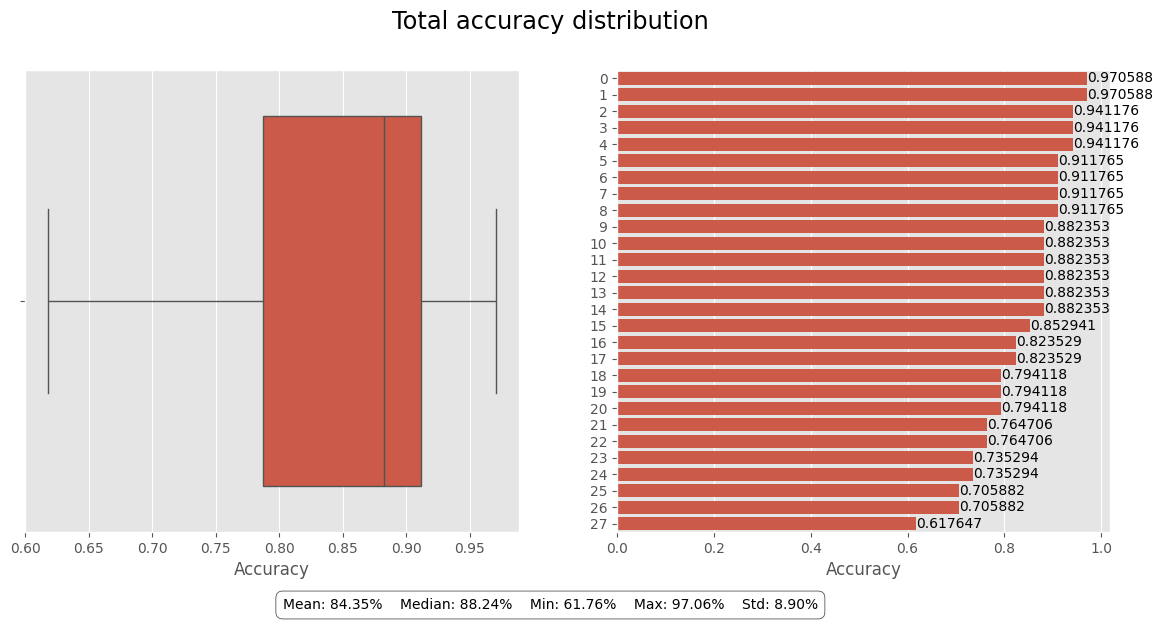

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle('Total accuracy distribution', fontsize='xx-large')

sns.boxplot(data=scores, ax=ax1, orient='h')
ax1.set_xlabel('Accuracy', fontsize='large')
text =  f'Mean: {100*np.mean(scores):.2f}%' \
        f'    Median: {100*np.median(scores):.2f}%' \
        f'    Min: {100*np.min(scores):.2f}%' \
        f'    Max: {100*np.max(scores):.2f}%' \
        f'    Std: {100*np.std(scores):.2f}%'

sns.barplot(y=np.arange(len(scores)), x=scores, ax=ax2, orient='h')
ax2.bar_label(ax2.containers[0])
ax2.set_xlabel('Accuracy', fontsize='large')


fig.text(0.5, 0, text, bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='black'), ha='center', va='top')
plt.show()

### Test

In [11]:
print(single_score(results[0]['prediction'], test_data[0]['messages'][2]['content'], verbose=2))

,LABELS,TRUTH,PREDICTION,SCORE
0,morfologia,solido_polipoide,solido_polipoide,1
1,posizione.basso,True,True,1
2,posizione.medio,False,False,1
3,posizione.alto,False,False,1
4,posizione.giunzione,False,False,1
5,ore_inizio,6,None,0
6,ore_fine,12,None,0
7,spessore_parietale,None,None,1
8,estensione_cranio_caudale,35,35,1
9,distanza_oai,0.0,0.0,0


total_score = 30
0.8823529411764706


# Analisi singole labels

In [12]:
compare_dict = {
    'index': [],
    'real': [],
    'prediction': []
}

for i in range(len(results)):
    if output_valido(results[i]['prediction']):
        pred_dict = json.loads(results[i]['prediction'])
        compare_dict['index'].append(i)
        compare_dict['real'].append(test_data[i]['messages'][2]['content'])
        compare_dict['prediction'].append(pred_dict)

In [13]:
labels = confronta_prediction(test_data[i]['messages'][2]['content'], test_data[i]['messages'][2]['content'])
labels = list(labels.LABELS)

pred_labels_dict = dict()
for label in labels:
    pred_labels_dict[label] = {
        'index': [],
        'real': [],
        'prediction': []
    }

for i in compare_dict['index']:
    df = confronta_prediction(compare_dict['prediction'][i], compare_dict['real'][i])
    for row in df.values:
        pred_labels_dict[row[0]]['real'].append(row[1])
        pred_labels_dict[row[0]]['prediction'].append(row[2])    
        pred_labels_dict[row[0]]['index'].append(i)    

morfologia


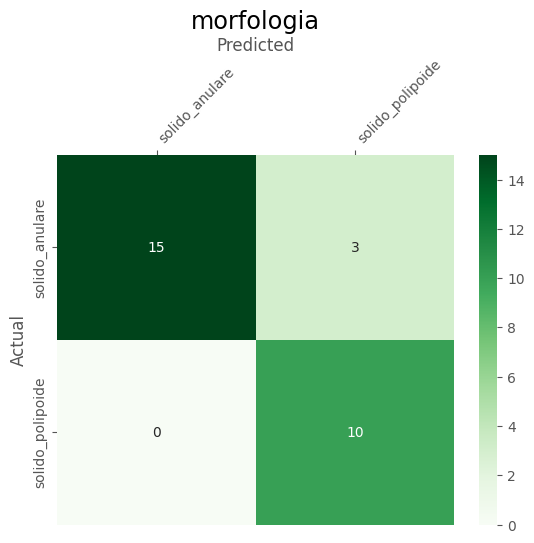

posizione.basso


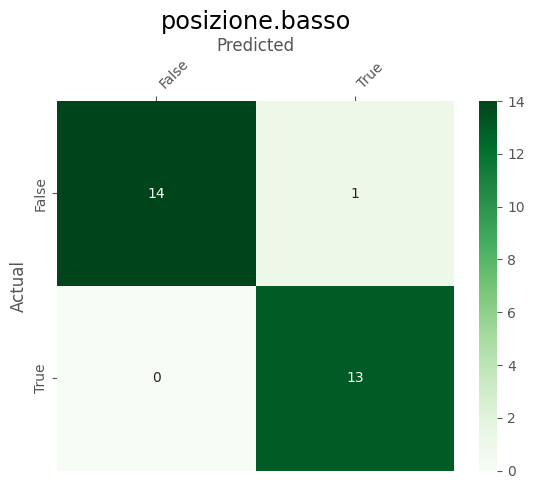

posizione.medio


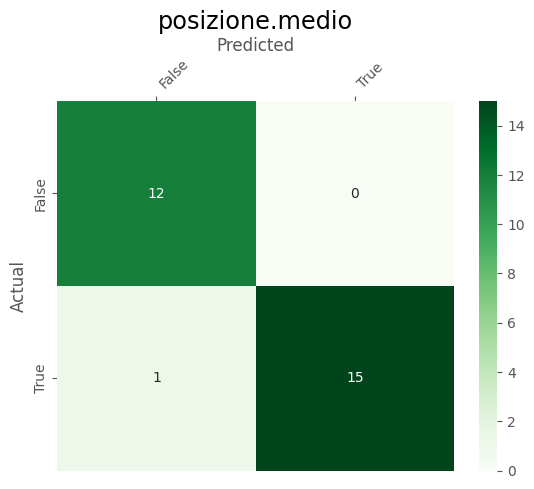

posizione.alto


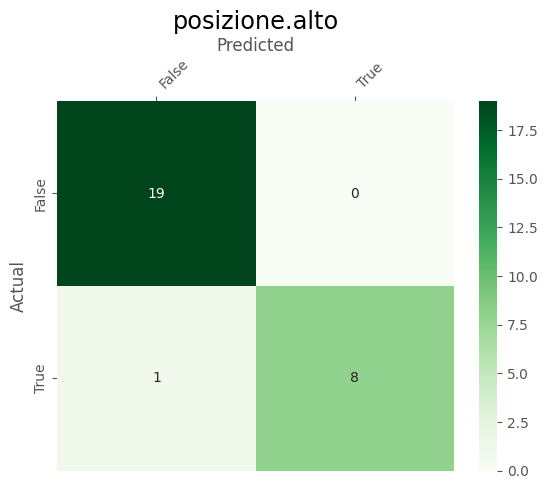

posizione.giunzione


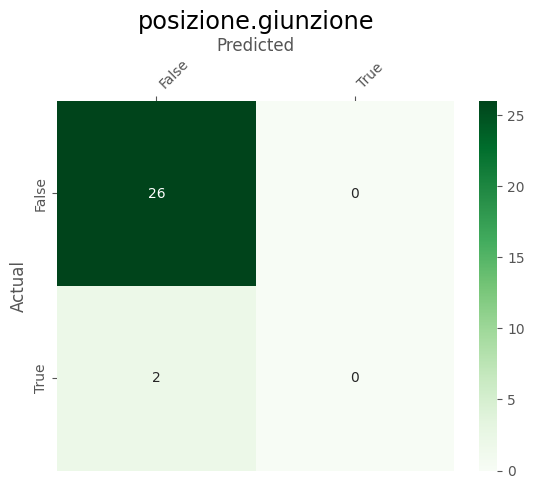

ore_inizio


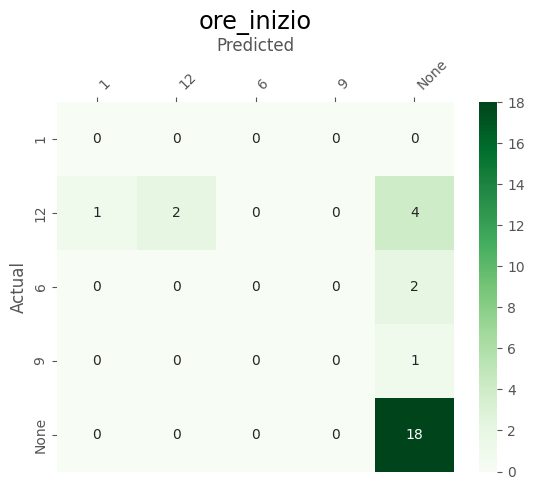

ore_fine


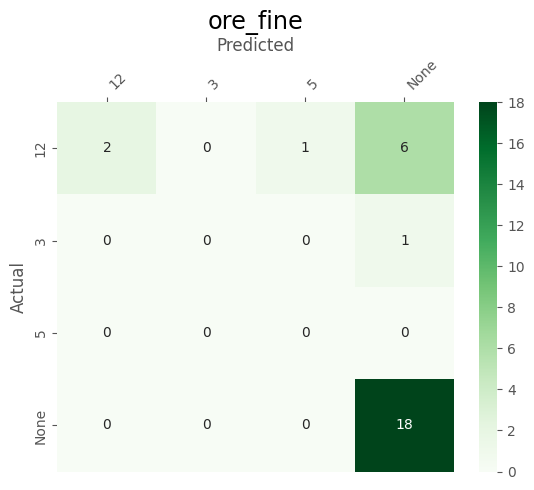

spessore_parietale


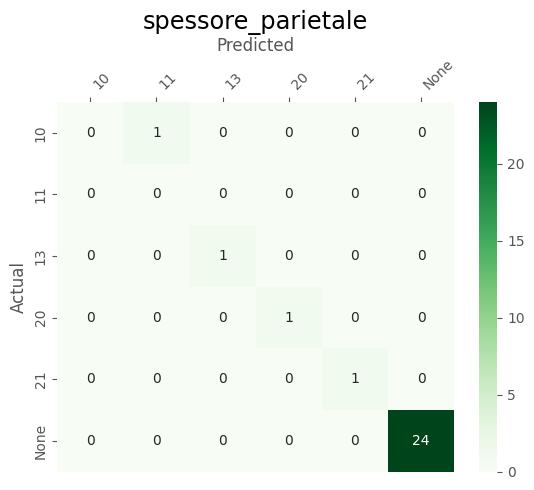

estensione_cranio_caudale


c:\Users\lucat\PythonProjects\PRIN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\lucat\PythonProjects\PRIN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


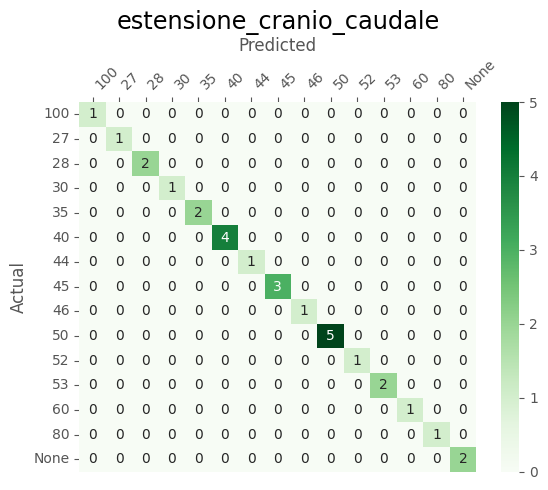

distanza_oai


c:\Users\lucat\PythonProjects\PRIN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
c:\Users\lucat\PythonProjects\PRIN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


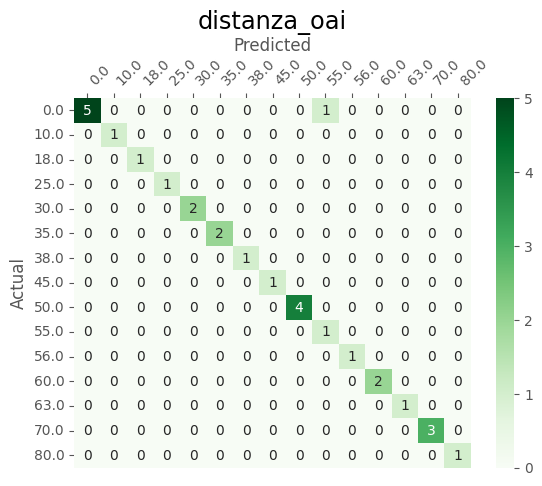

riflessione_peritoneale_anteriore


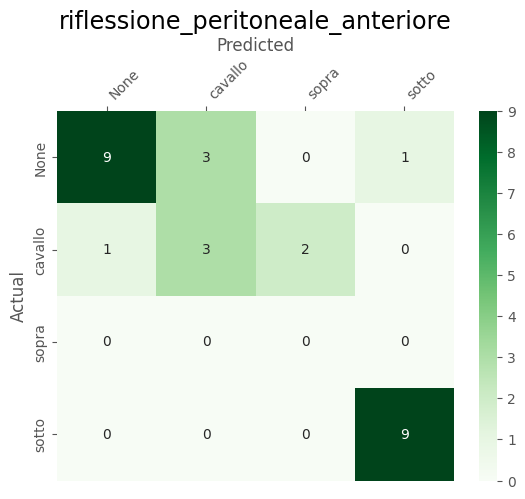

infiltrazione_tessuto_adiposo


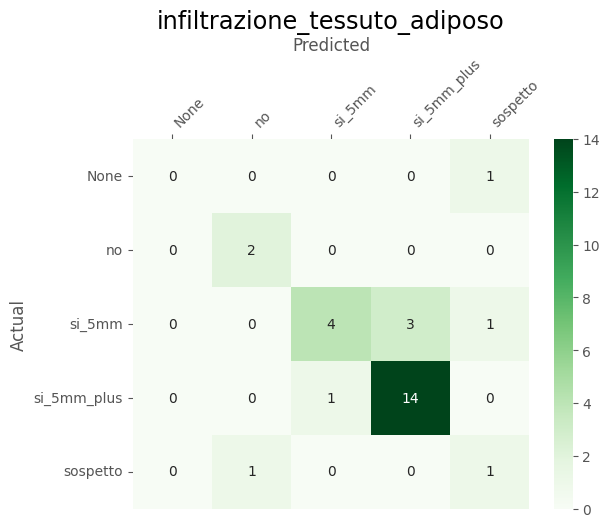

infiltrazione_sfinteri


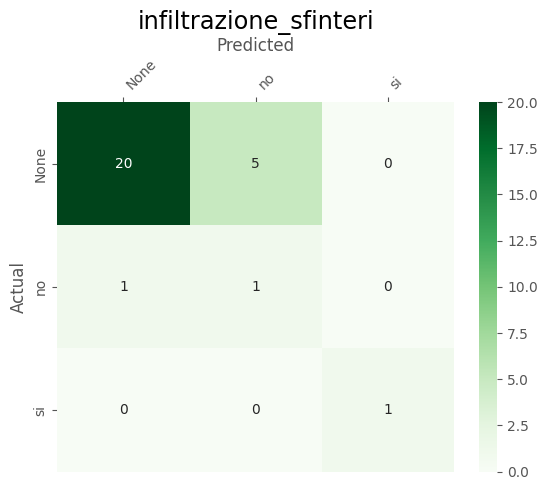

infiltrazione_organi_extra


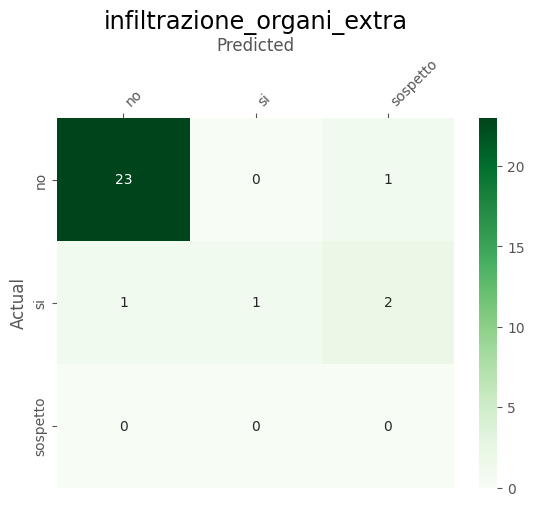

infiltrazione_organi_dettagli.pavimento_pelvico


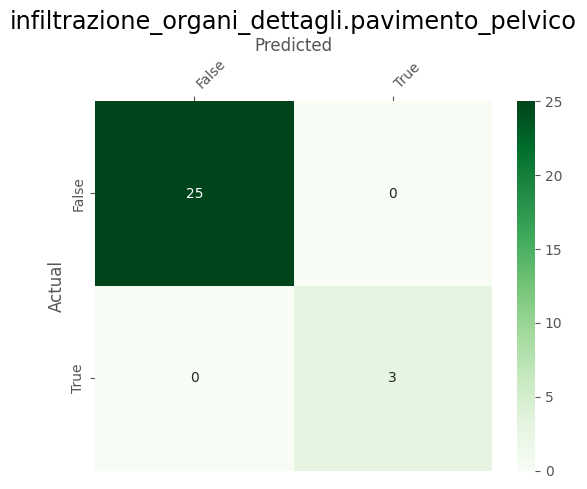

infiltrazione_organi_dettagli.altro


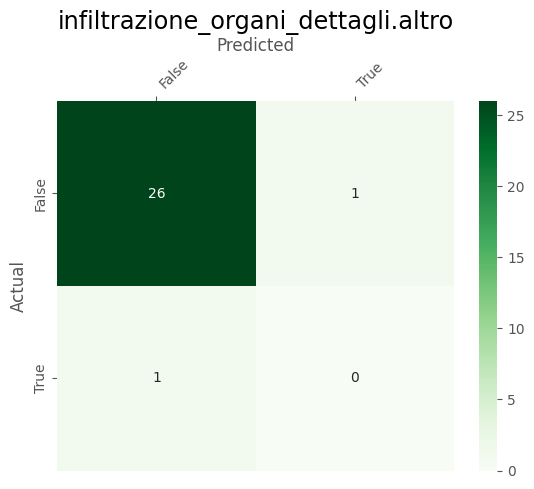

coinvolgimento_riflessione_peritoneale


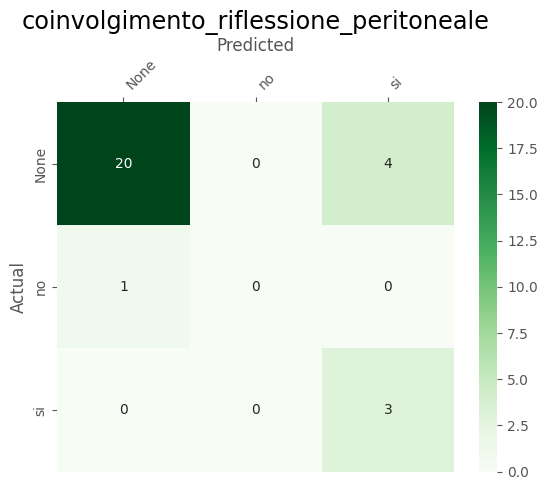

coinvolgimento_fascia_mesorettale


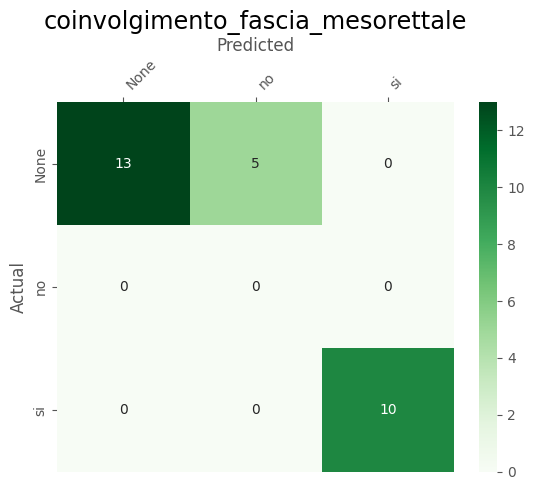

numero_linfonodi_non_conosciuto


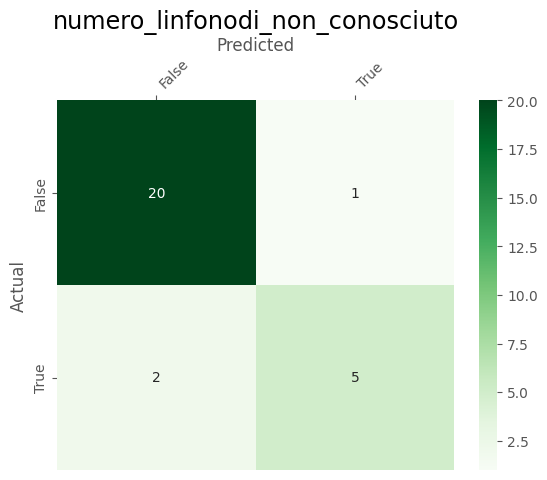

linfonodi_sospetti


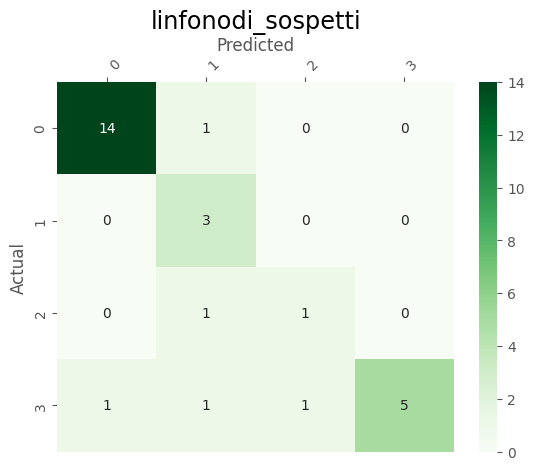

sedi_linfonodi.mesorettali


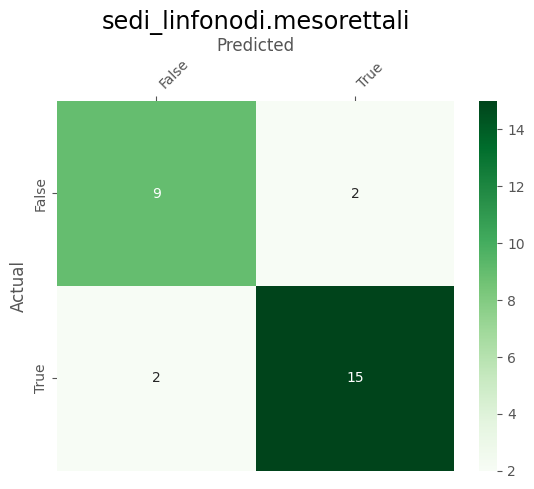

sedi_linfonodi.rettali_superiori


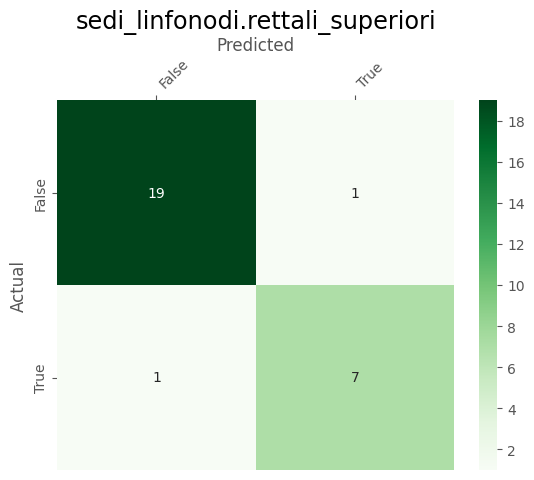

sedi_linfonodi.otturatori


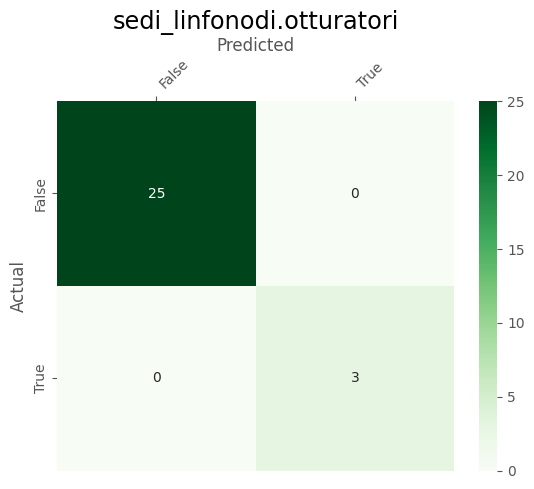

sedi_linfonodi.iliaci


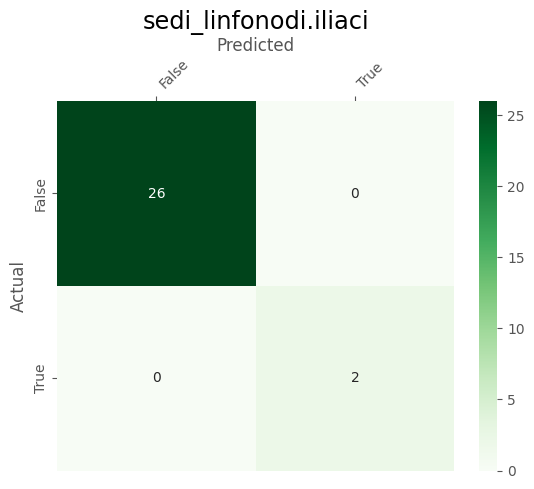

sedi_linfonodi.altro


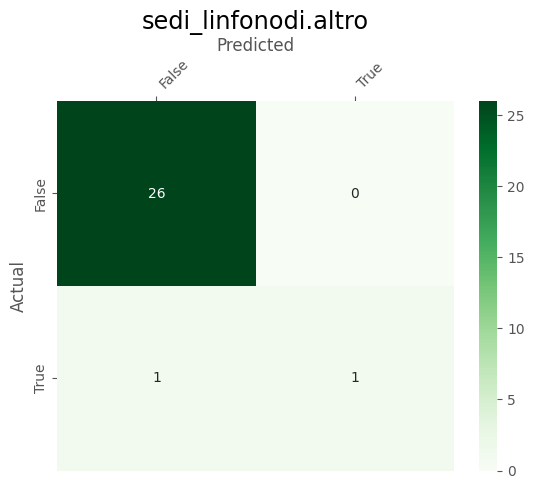

depositi_tumorali


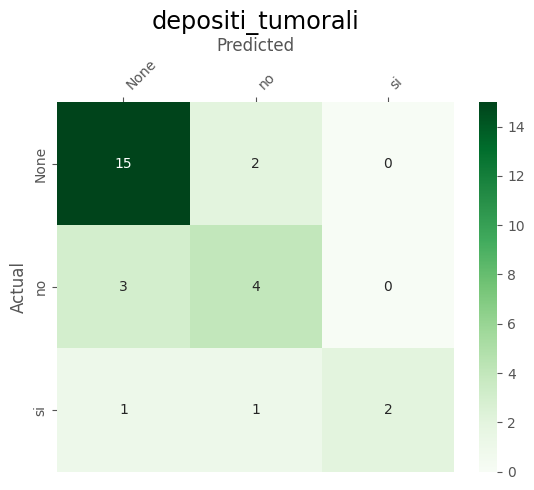

numero_depositi


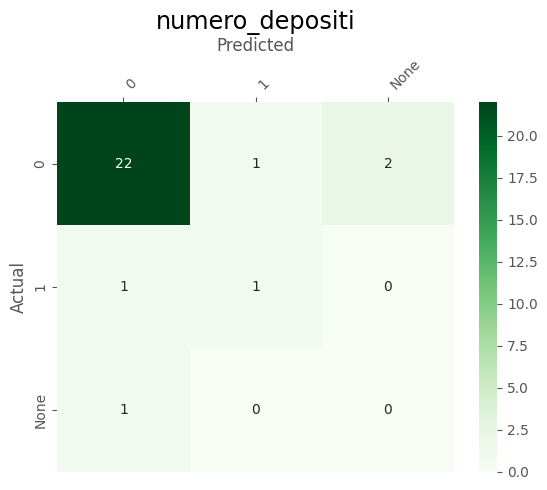

emvi_esteso


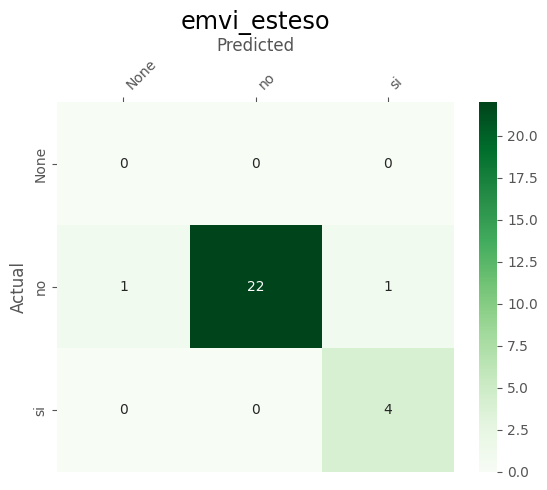

stadio_T


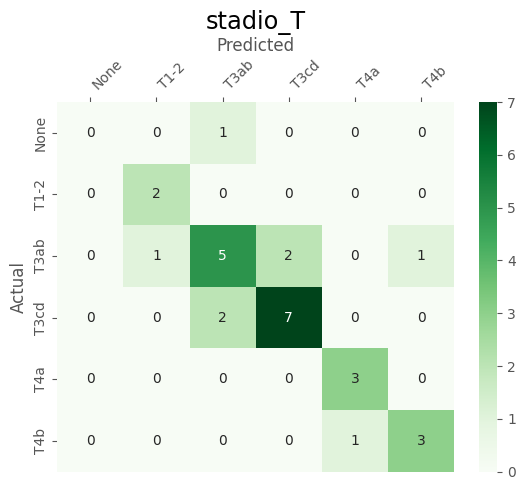

stadio_N


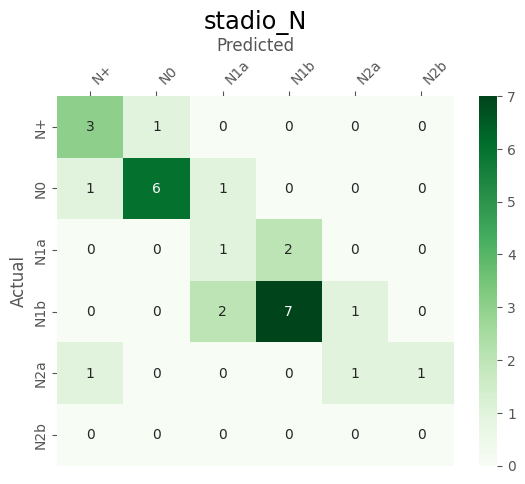

stadio_N1c


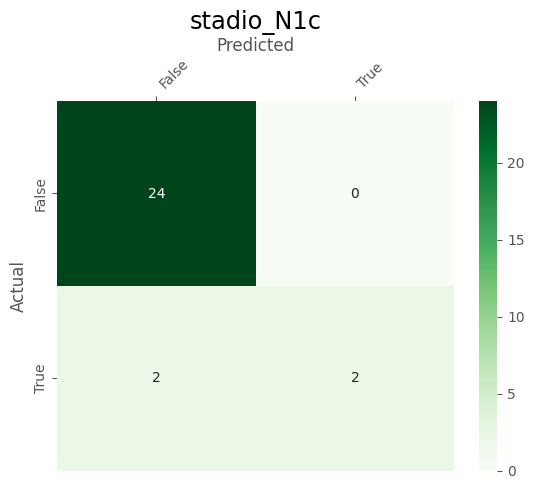

mrf


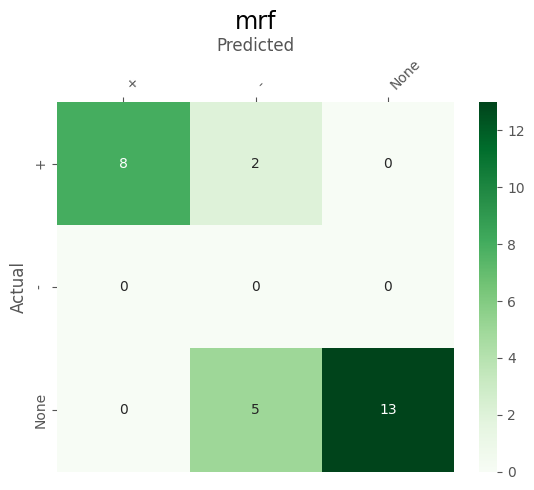

emvi


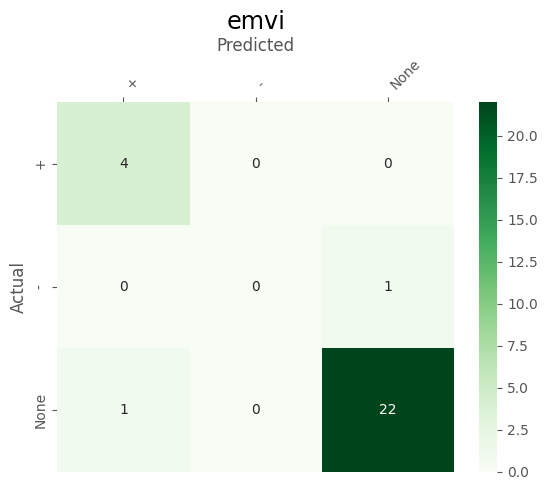

metastasi


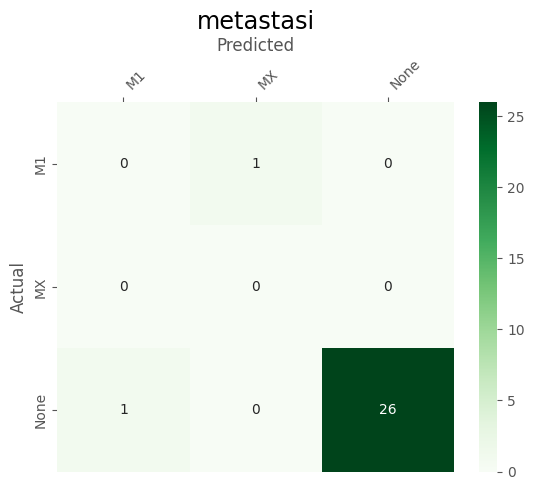

In [14]:
for label in labels:
    print(label)
    y_true = [str(x) for x in pred_labels_dict[label]['real']]
    y_pred = [str(x) for x in pred_labels_dict[label]['prediction']]

    fig, ax = plt.subplots()
    class_labels = np.unique(np.concatenate([y_true, y_pred]))

    cm = confusion_matrix(y_true, y_pred, labels=class_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(label, fontsize='xx-large')
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')  # anche il titolo dell'asse X va sopra

    plt.xticks(rotation=45, ha='left')
    plt.show()
